##Preparação dos Dados

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/leonardo-queiroz/challenge-telecom-x-parte-2/refs/heads/main/data/telecom_X.csv")

In [ ]:
df.head()

,id_cliente,evasao,genero,idoso,parceiro,dependentes,tempo_contrato,servico_telefone,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,custo_diario
0,0002-ORFBO,0,Feminino,0,1,1,9,1,Não,DSL,...,Não,Sim,Sim,Não,Anual,1,Cheque por correio,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Sim,DSL,...,Não,Não,Não,Sim,Mensal,0,Cheque por correio,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,1,Cheque eletrônico,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,1,Cheque eletrônico,98.0,1237.85,3.27
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,1,Cheque por correio,83.9,267.40,2.80


In [ ]:
df = df.drop(columns=["id_cliente", "custo_diario"])

In [ ]:
X = df.drop(columns=["evasao"])
y = df["evasao"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Shape após encoding (treino):", X_train_encoded.shape)
print("Shape após encoding (teste):", X_test_encoded.shape)

Shape após encoding (treino): (5634, 30)
Shape após encoding (teste): (1409, 30)


In [ ]:
class_counts = df["evasao"].value_counts()

class_proportion = df["evasao"].value_counts(normalize=True)

print("Frequência absoluta:")
print(class_counts)

print("\nFrequência relativa:")
print(class_proportion)

Frequência absoluta:
evasao
0    5174
1    1869
Name: count, dtype: int64

Frequência relativa:
evasao
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [ ]:
print("Treino antes do balanceamento:", X_train.shape)
print("Distribuição antes:")
print(y_train.value_counts(normalize=True))

Treino antes do balanceamento: (5634, 19)
Distribuição antes:
evasao
0    0.734647
1    0.265353
Name: proportion, dtype: float64


##Correlação e Seleção de Variáveis

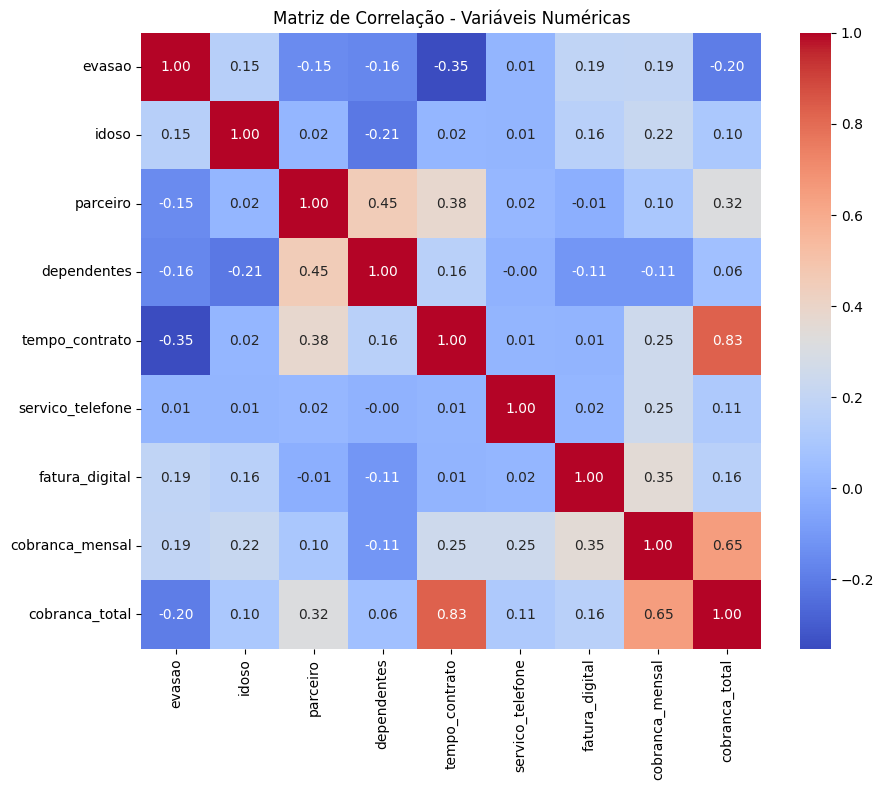

In [ ]:
num_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = num_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

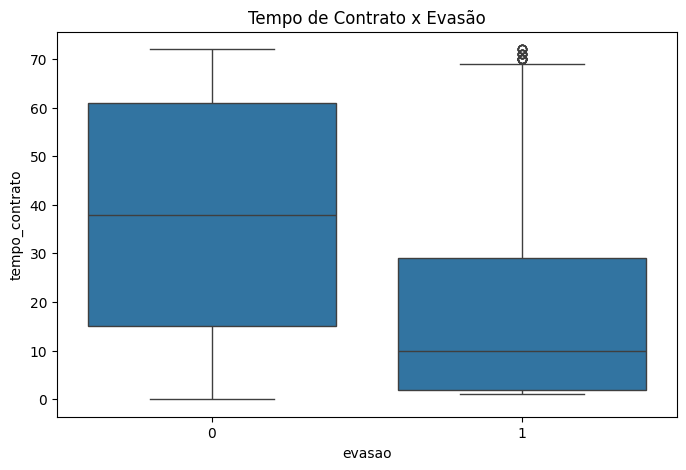

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='evasao', y='tempo_contrato', data=df)
plt.title("Tempo de Contrato x Evasão")
plt.show()

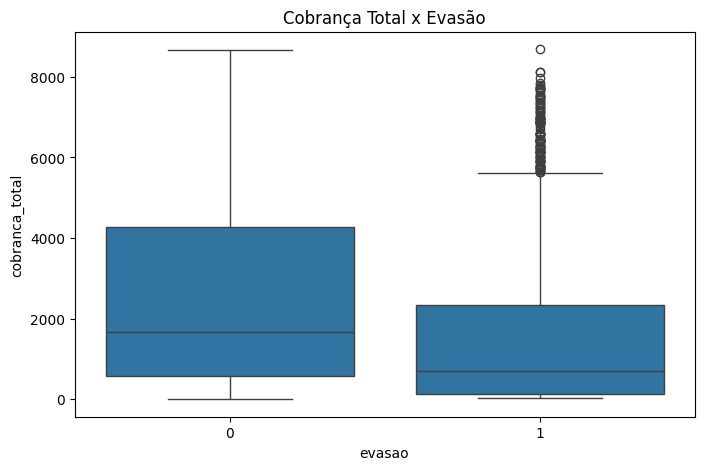

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='evasao', y='cobranca_total', data=df)
plt.title("Cobrança Total x Evasão")
plt.show()

##Modelagem Preditiva

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

X = df.drop(columns=['evasao'])
y = df['evasao']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape treino:", X_train.shape)
print("Shape teste:", X_test.shape)

print("\nDistribuição treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição teste:")
print(y_test.value_counts(normalize=True))

Shape treino: (5634, 19)
Shape teste: (1409, 19)

Distribuição treino:
evasao
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Distribuição teste:
evasao
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Sobre a escolha dos modelos, decidi criar um modelo que precisa de normalização e outro que não precisa, pois acho que será interessante comparar a eficiência dos dois. A normalização é necessária porque evita que uma variável domina as outras, melhora a convergência do algoritmo e auxilia na interpretação dos coeficientes. Um coeficiente pode parecer pequeno apenas porque a variável tem valores grandes, mas com a normalização a comparação fica mais justa.

O modelo escolhido que precisa de normalização foi o modelo de regressão logística. Ele é o baseline padrão em churn, é extremamente interpretável e permite analisar coeficientes. Fora que funciona muito bem com esse tamanho de dataset. É um modelo ótimo para gerar insights estratégicos depois.

O modelo escolhido que não precisa de normalização, foi random forest. Ele lida muito bem com dados tabulares, captura não-linearidade e não sofre com escala. E ele vai conseguir rodar bem rápido com as a quantidade de registros que esse dataset possui.

####Modelo de Regressão Logística

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

log_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC: 0.8431798806479112

Matriz de Confusão:

[[922 113]
 [179 195]]


####Modelo Random Forest

In [ ]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC-AUC: 0.8240964633547754

Matriz de Confusão:

[[931 104]
 [196 178]]


Comparando o desempenho dos dois modelos, percebe-se que o modelo de regressão logística teve desempenho ligeiramente superior em quase todas as métricas relevantes. A random forest reduziu levemente falsos positivos, mas aumentou falsos negativos. Como ela possuiu um FN maior, conclui-se que ela perdeu mais positivos. O que acaba sendo um problema relevante, considerando que a classe 1 é a classe crítica nesse caso (churn).

A regressão logística separou melhor as classes ao longo de todos os thresholds. Não há indícios fortes de overfitting porque o desempenho não é exageradamente alto, nem há comportamento extremamente enviesado.

##Análise de Importância das Variáveis

Coeficiente das variáveis de regressão logística

In [ ]:
preprocessor = log_model.named_steps['preprocessing']
model = log_model.named_steps['model']

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_feature_names = list(cat_feature_names) + list(num_cols)

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'variavel': all_feature_names,
    'coeficiente': coefficients
})

coef_df['abs_coef'] = coef_df['coeficiente'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df.head(15)

,variavel,coeficiente,abs_coef
25,tempo_contrato,-1.413473,1.413473
3,servico_internet_Fibra óptica,0.858375,0.858375
18,tipo_contrato_Mensal,0.690530,0.690530
29,cobranca_total,0.682719,0.682719
17,tipo_contrato_Dois anos,-0.663610,0.663610
12,suporte_tecnico_Sim,-0.401376,0.401376
21,metodo_pagamento_Transferência bancária automá...,-0.398205,0.398205
20,metodo_pagamento_Cobrança recorrente no cartão,-0.389962,0.389962
19,metodo_pagamento_Cheque por correio,-0.367204,0.367204
2,multiplas_linhas_Sim,0.332371,0.332371


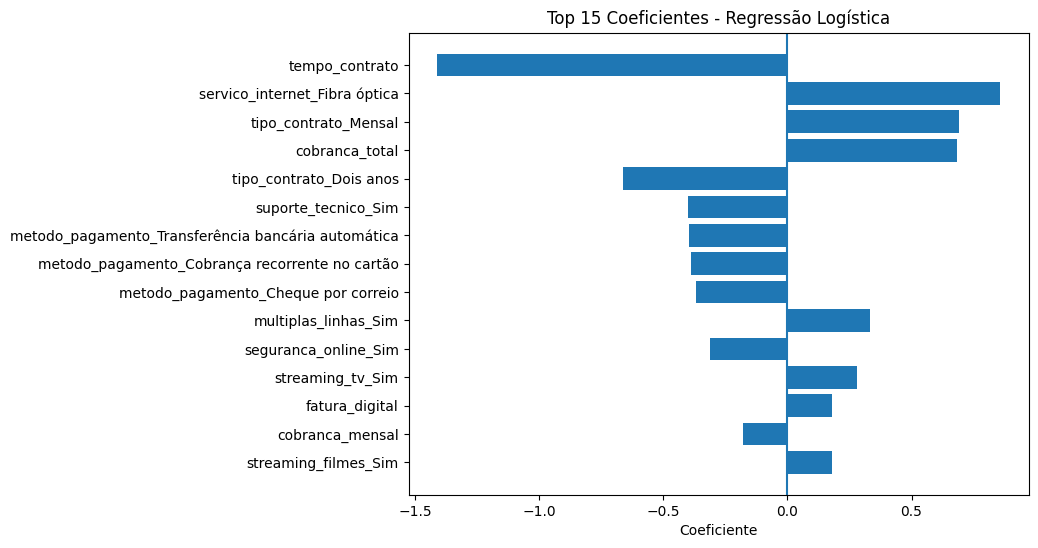

In [ ]:
top_n = 15
top_coef = coef_df.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_coef['variavel'][::-1], top_coef['coeficiente'][::-1])
plt.title("Top 15 Coeficientes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.axvline(x=0)
plt.show()

Importância das variáveis de Random Forest

In [ ]:
preprocessor_rf = rf_model.named_steps['preprocessing']
rf = rf_model.named_steps['model']

cat_feature_names = preprocessor_rf.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_feature_names_rf = list(cat_feature_names) + list(num_cols)

importances = rf.feature_importances_

rf_importance_df = pd.DataFrame({
    'variavel': all_feature_names_rf,
    'importancia': importances
})

rf_importance_df = rf_importance_df.sort_values(by='importancia', ascending=False)

rf_importance_df.head(15)

,variavel,importancia
29,cobranca_total,0.189982
28,cobranca_mensal,0.164871
25,tempo_contrato,0.160217
18,tipo_contrato_Mensal,0.073930
3,servico_internet_Fibra óptica,0.036343
0,genero_Masculino,0.026810
27,fatura_digital,0.024944
23,parceiro,0.023475
12,suporte_tecnico_Sim,0.022831
6,seguranca_online_Sim,0.022504


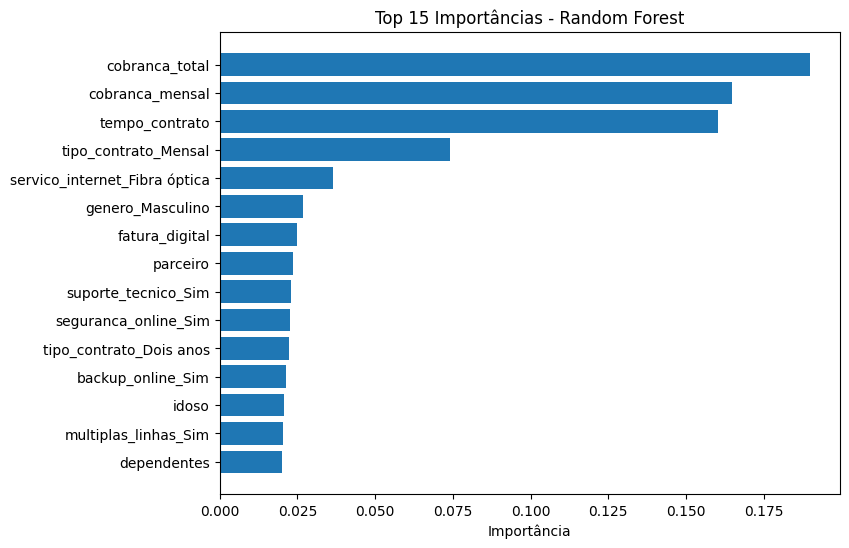

In [ ]:
top_n = 15
top_features = rf_importance_df.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top_features['variavel'][::-1], top_features['importancia'][::-1])
plt.title("Top 15 Importâncias - Random Forest")
plt.xlabel("Importância")
plt.show()

#Relatório Final

O objetivo desse projeto foi desenvolver modelos preditivos capazes de identificar clientes com maior probabilidade de evasão, utilizando técnicas de Machine Learning para identificar fatores determinantes do churn, avaliar desempenho de diferentes modelos e propor estratégias de retenção com base nos resultados obtidos. A base analisada contava com 7.043 clientes e 20 variáveis após o tratamento.

Durante a análise exploratória, ao avaliar a distribuição da variável alvo, constatou-se que a taxa de evasão é de 26,53%. O que significa que existe um desabalanceamento moderado, mas não é extremo. Também foi avaliada a correlação entre variáveis, utilizando uma matriz de correlação. Ela revelou que existe uma forte relação negativa entre o tempo de contrato e a taxa de evasão, ou seja, clientes com tempo de contrato longo têm uma chance menor de cancelar o serviço. Sendo que a maioria dos clientes que cancelam, fazem isso nos primeiros 12 meses, algo que a matriz também mostrou, pois clientes com menor gasto acumulado concentram maior evasão.

Foram testados dois modelos principais, um de regressão logística e outro de random forest. O modelo de regressão logística teve um bom desempenho: accuracy de 79%, ROC-AUC de 0.84 e recall classe 1 (evasão) de 52%. Trata-se de um modelo com bom poder discriminativo. O modelo de random forest apresentou uma accuracy de 79% também, uma ROC-AUC de 0.82 e recall classe 1 de 48%. O desempenho foi semelhante ao primeiro modelo, mas foi um pouco inferior na identificação de evasão.

A análise conjunta dos coeficientes da regressão logística e da importância do random forest mostrou convergência consistente, deixando claro os principais fatores que influenciam a evasão. O mais evidente é o tipo de contrato, clientes que assinam o plano mensal cancelam muito mais que os outros, provavelmente por existir uma baixa barreira de saída nesse plano. Em segundo lugar estão os assinantes de fibra óptica, isso pode estar associado ao preço elevado ou um problema de qualidade. A análise reforçou o que foi observado na matriz de correlação, clientes novos são significativamente mais propensos a cancelar. E também o preço elevado impacta na retenção.

Também foi possível observar fatores que reduzem a evasão. Os clientes com maior tempo de contrato eram os clientes com menor taxa de evasão. Além disso, contratos longos, como o de dois anos, criam estabilidade e reduzem churn drasticamente. Algo interessante observado é que clientes com muitos serviços adicionais, como suporte técnico, seguro e backup, possuíam uma taxa de evasão menor apesar do valor mais alto de mensalidade. Ou seja, clientes mais engajados permanecem mais. Por fim, foi observado que métodos de pagamentos automáticos reduzem a fricção e consequentemente aumentam a retenção.

Essa análise deixou claro que a evasão não é aleatória. Ela é muito influenciada pela estrutura contratual, pelo tempo de relacionamento, por sensibilidade a preço e pelo grau de engajamento com serviços adicionais. Os modelos mostraram que o churn é mais comportamental e estrutural do que demográfico, já que variáveis como gênero e idade tiveram baixo impacto. Levando isso em conta, foram preparadas algumas estratégias para auxiliar na retenção de clientes.

A empresa precisa dar muita atenção à experiência dos novos clientes nos primeiros 6 a 12 meses. Esse período é quando o maior risco de cancelamento está concentrado. Então, campanhas de onboarding, benefícios exclusivos para esses novos clientes e até mesmo acompanhamento ativo no primeiro ano todo, seriam de grande ajuda para segurar esses novos clientes.

É preciso incentivar contratos de longo prazo, seja com descontos progressivos, benefícios exclusivos para os planos anuais ou programas de fidelidade. Como contratos mensais são o maior fator estrutural de evasão, é preciso aumentar o interesse pelos outros contratos. Algo semelhante pode ser feito para incentivar métodos de pagamentos automáticos, com uma menor fricção, os clientes ficam mais confortáveis mantendo seus planos.

Uma estratégia precisa ser pensada especialmente para o serviço de fibra óptica, pois é outra área com risco elevado de churn. Podem ser feitas ofertas personalizadas para esse setor, pesquisas de satisfação e monitoramento da qualidade do serviço. Por fim, como clientes com serviços adicionais cancelam menos, poderiam ser criados pacotes promocionais ou testes gratuitos desses serviços extras.

Os modelos apresentaram bom desempenho (ROC-AUC ~0.84) e revelaram padrões claros: o tempo de relacionamento é o principal fator protetor, contratos curtos aumentam risco, engajamento com serviços reduz evasão e a estrutura de preço influencia a decisão de cancelamento. A empresa tem alavancas claras para atuar e conseguir controlar esse churn.

